# Simplex Tree Approximation of a Classifier

Given any classifier, approximate its decision boundary using a **SimplexTreeClassifier**:
1. Generate a dense grid on [0,1]×[0,1]
2. Label grid points with the classifier
3. Fit a SimplexTreeClassifier on that labeled grid
4. Compare the exact classifier prediction vs. the simplex-tree approximation
5. Check non-convexity of the boundary region around a test point

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys, os, warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.classifying.classes.utilss.convexity_check import check_convexity, get_shared_vertices

np.random.seed(42)

In [11]:
def make_meshgrid(x, y, h=0.01):
    xx, yy = np.meshgrid(np.arange(x.min(), x.max(), h),
                         np.arange(y.min(), y.max(), h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, xy, **params):
    Z = clf.predict(xy)
    Z = Z.reshape(xx.shape)
    return ax.contourf(xx, yy, Z, **params)

### Data Loading

Generated ../datasets/dataset_polygon_notch.npz
Dataset: 800 points, Classes: [-1.  1.]
Distribution: {-1.0: 400, 1.0: 400}
Exact classifier accuracy: 100.00%


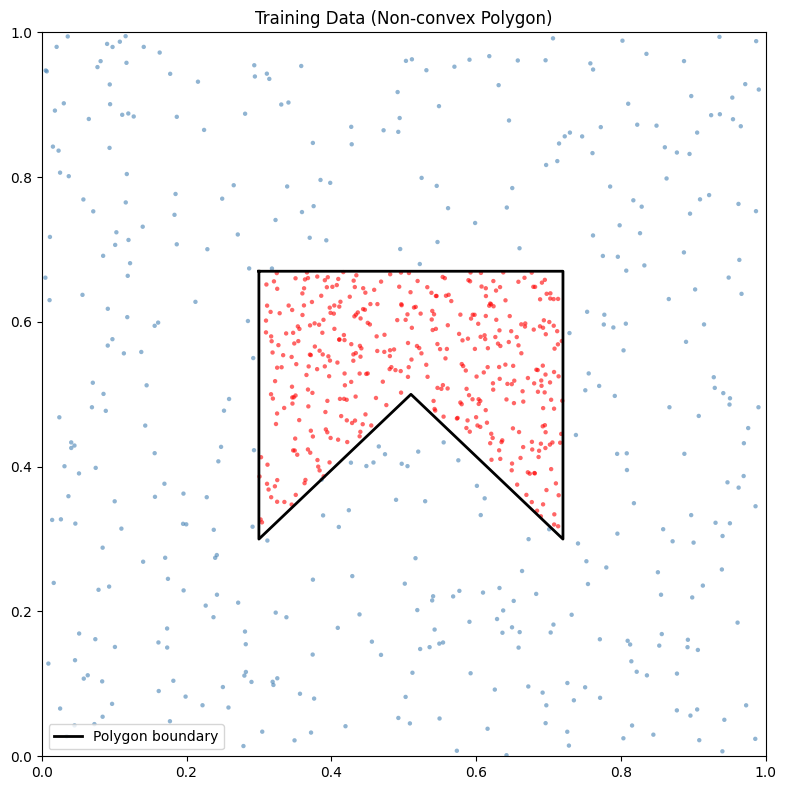

In [12]:
from matplotlib.path import Path

POLYGON_VERTICES = np.array([
    [0.3, 0.67],
    [0.3, 0.3],
    [0.51, 0.5],
    [0.72, 0.3],
    [0.72, 0.67],
])
POLYGON_PATH = Path(POLYGON_VERTICES)

def shape_classify(pts):
    pts = np.atleast_2d(pts)
    return np.where(POLYGON_PATH.contains_points(pts), 1.0, -1.0)

class ExactClassifier:
    def predict(self, pts):
        return shape_classify(pts)
    def fit(self, X, y):
        return self

dataset_path = '../datasets/dataset_polygon_notch.npz'
REGENERATE = True

if REGENERATE or not os.path.exists(dataset_path):
    np.random.seed(42)
    n_samples = 50000
    raw_pts = np.column_stack([np.random.uniform(0, 1, n_samples),
                               np.random.uniform(0, 1, n_samples)])
    raw_labels = shape_classify(raw_pts)
    inside_idx = np.where(raw_labels == 1.0)[0]
    outside_idx = np.where(raw_labels == -1.0)[0]
    n_min = min(len(inside_idx), len(outside_idx), 400)
    keep = np.concatenate([inside_idx[:n_min], outside_idx[:n_min]])
    np.random.shuffle(keep)
    np.savez(dataset_path, X=raw_pts[keep], y=raw_labels[keep])
    print(f"Generated {dataset_path}")

data = np.load(dataset_path)
X, y = data['X'], data['y']

clf = ExactClassifier()
print(f"Dataset: {X.shape[0]} points, Classes: {np.unique(y)}")
print(f"Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Exact classifier accuracy: {accuracy_score(y, clf.predict(X)):.2%}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y],
           s=10, alpha=0.6, edgecolors='none')
poly_closed = np.vstack([POLYGON_VERTICES, POLYGON_VERTICES[0]])
ax.plot(poly_closed[:, 0], poly_closed[:, 1], 'k-', linewidth=2, label='Polygon boundary')
ax.set_title('Training Data (Non-convex Polygon)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()


## Approximate the classifier with a SimplexTreeClassifier

In [13]:
def approximate_with_simplex_tree(classifier_predict,
                                  subdivision_levels=4, C=10000, alpha=5):
    """
    Approximate any classifier's decision boundary using a SimplexTreeClassifier.
    C:      higher == Less regulrization
    alpha:  higher == more regulrization
    """

    grid_points = X
    grid_labels = y
    print(X.shape)
    model = SimplexTreeClassifier(
        vertices=[(0, 0), (2, 0), (0, 2)],
        # classifier=LogisticRegression(C=100, max_iter=1000),
        classifier=LinearSVC(C=C),
        # classifier=DecisionTreeClassifier(max_depth=20),
        # classifier=Perceptron(max_iter=1000, alpha=alpha),
        subdivision_levels=subdivision_levels,
    )
    model.fit(grid_points, grid_labels)
    return model, grid_points, grid_labels

stc_model, grid_pts, grid_labels = approximate_with_simplex_tree(clf.predict)
stc_acc = accuracy_score(grid_labels, stc_model.predict(grid_pts))
print(f'SimplexTree approximation accuracy on grid: {stc_acc:.2%}')
print(f'Leaf simplices: {len(stc_model.leaf_simplexes)}')

(800, 2)
SimplexTree approximation accuracy on grid: 97.50%
Leaf simplices: 81


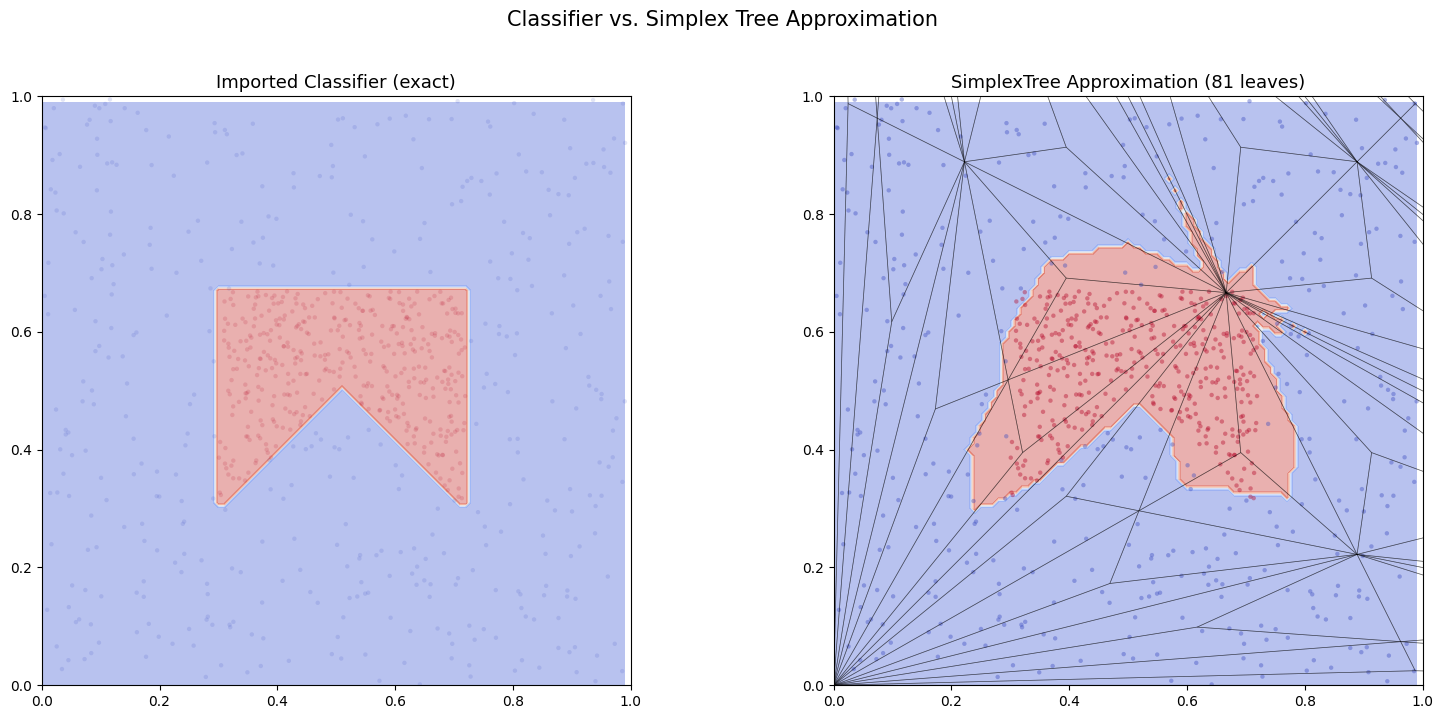

In [14]:
xx, yy = make_meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
Z_clf = clf.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
ax.contourf(xx, yy, Z_clf, cmap=plt.cm.coolwarm, alpha=0.4)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.15)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Imported Classifier (exact)', fontsize=13)

# Right: simplex tree approximation
ax = axes[1]
xy_stc = stc_model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, stc_model.classifier, xx, yy, xy_stc, cmap=plt.cm.coolwarm, alpha=0.4)

for boundary in stc_model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=0.5, alpha=0.4)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.4)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title(f'SimplexTree Approximation ({len(stc_model.leaf_simplexes)} leaves)', fontsize=13)

plt.suptitle('Classifier vs. Simplex Tree Approximation', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Non-convexity check around a test point

Crossing simplices: 27
Non-convex simplices: 21
Same-side simplices: 42


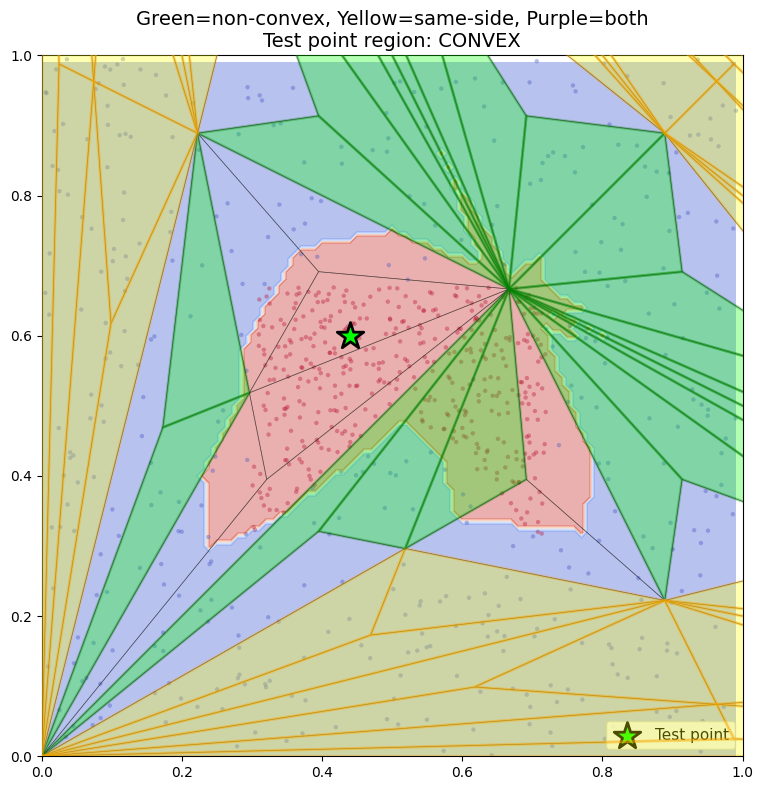


Test point (0.44, 0.60) is in a CONVEX region.


In [15]:
test_point = np.array([0.44, 0.6])
EPSILON = 0.30

crossing_simplices = stc_model.identify_crossing_simplices()

nonconvex_simplex_keys = set()
same_side_simplex_keys = set()

if stc_model.is_linear_classifier:
    weights, intercept = stc_model.get_weights_and_intercept()
    for i, info1 in enumerate(crossing_simplices):
        simplex1 = info1['simplex']
        for info2 in crossing_simplices[i+1:]:
            simplex2 = info2['simplex']
            shared = get_shared_vertices(simplex1, simplex2)
            if len(shared) >= 2:
                is_convex, avg, meeting, pt1, pt2 = check_convexity(
                    simplex1, simplex2, weights, intercept,
                    global_tree=stc_model.tree, epsilon=EPSILON
                )
                if not is_convex:
                    nonconvex_simplex_keys.add(frozenset(simplex1.vertex_indices))
                    nonconvex_simplex_keys.add(frozenset(simplex2.vertex_indices))
    same_side_simplex_keys = stc_model.find_same_side_simplices()
else:
    print("Convexity check requires a linear classifier inside SimplexTreeClassifier")

print(f'Crossing simplices: {len(crossing_simplices)}')
print(f'Non-convex simplices: {len(nonconvex_simplex_keys)}')
print(f'Same-side simplices: {len(same_side_simplex_keys)}')

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
xy_stc = stc_model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, stc_model.classifier, xx, yy, xy_stc, cmap=plt.cm.coolwarm, alpha=0.4)

for boundary in stc_model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=0.5, alpha=0.4)

# Highlight crossing simplices in yellow, non-convex in red
for leaf in stc_model.leaf_simplexes:
    simplex_key = frozenset(leaf.vertex_indices)
    is_nonconvex = simplex_key in nonconvex_simplex_keys
    is_same_side = simplex_key in same_side_simplex_keys
    if is_nonconvex and is_same_side:
        color, edge = 'purple', 'darkviolet'
    elif is_nonconvex:
        color, edge = 'lime', 'green'
    elif is_same_side:
        color, edge = 'yellow', 'orange'
    else:
        continue
    vertices = np.array(leaf.vertices)
    poly = patches.Polygon(vertices, closed=True, facecolor=color, alpha=0.3,
                           edgecolor=edge, linewidth=2, zorder=6)
    ax.add_patch(poly)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.35)

# Mark the test point
ax.scatter(*test_point, c='lime', s=400, marker='*',
           edgecolors='k', linewidths=2, zorder=20, label='Test point')

grid_min = grid_pts.min(axis=0)
grid_max = grid_pts.max(axis=0)
test_normalized = (test_point - grid_min) / (grid_max - grid_min + 1e-10)
test_in_nonconvex = False
for leaf in stc_model.leaf_simplexes:
    if frozenset(leaf.vertex_indices) in nonconvex_simplex_keys:
        if leaf._point_inside_simplex(tuple(test_normalized)):
            test_in_nonconvex = True
            break

status = 'NON-CONVEX' if test_in_nonconvex else 'CONVEX'
ax.set_title(f'Green=non-convex, Yellow=same-side, Purple=both\n'
             f'Test point region: {status}', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'\nTest point ({test_point[0]:.2f}, {test_point[1]:.2f}) is in a {status} region.')

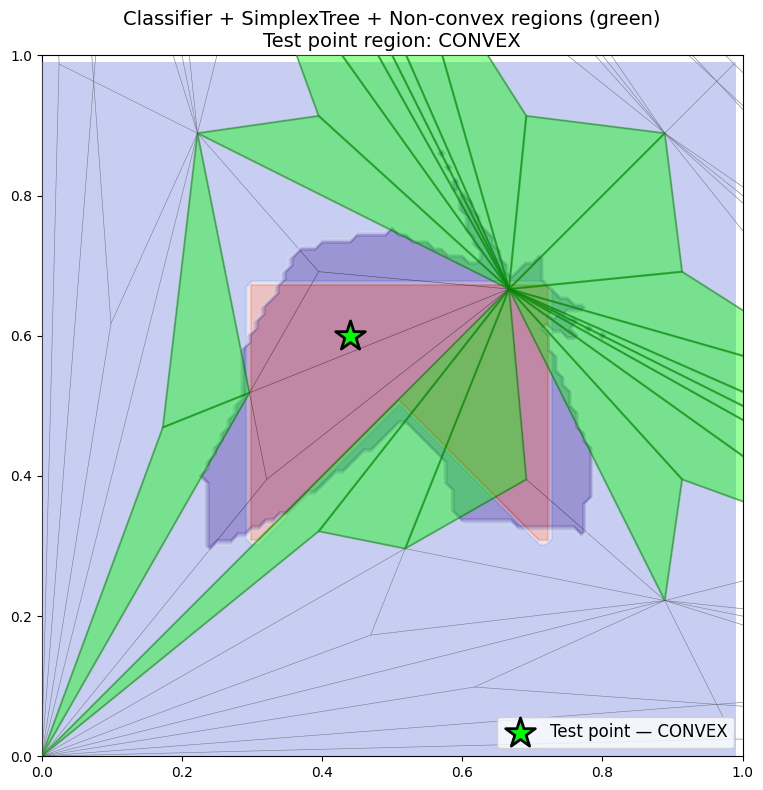

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

# Layer 1: Real classifier decision regions (bottom)
Z_clf = clf.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
ax.contourf(xx, yy, Z_clf, cmap=plt.cm.coolwarm, alpha=0.4)

# Layer 2: Simplex tree classification as light purple fill
xy_stc = stc_model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
Z_stc = stc_model.classifier.predict(xy_stc).reshape(xx.shape)
ax.contourf(xx, yy, Z_stc, cmap=plt.cm.Purples, alpha=0.25, zorder=3)

for boundary in stc_model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=0.4, alpha=0.3)

# Layer 3: Non-convex regions in green + test point
for leaf in stc_model.leaf_simplexes:
    simplex_key = frozenset(leaf.vertex_indices)
    if simplex_key in nonconvex_simplex_keys:
        vertices = np.array(leaf.vertices)
        poly = patches.Polygon(vertices, closed=True, facecolor='lime', alpha=0.4,
                               edgecolor='green', linewidth=1.5, zorder=6)
        ax.add_patch(poly)

ax.scatter(*test_point, c='lime', s=500, marker='*',
           edgecolors='k', linewidths=2, zorder=20,
           label=f'Test point — {status}')

ax.legend(fontsize=12, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title(f'Classifier + SimplexTree + Non-convex regions (green)\n'
             f'Test point region: {status}', fontsize=14)
plt.tight_layout()
plt.show()

Leaves before removal: 81
Leaves after removal:  31
Removed 25 parent splits
Non-convex simplices remaining: 9
Same-side simplices remaining: 9


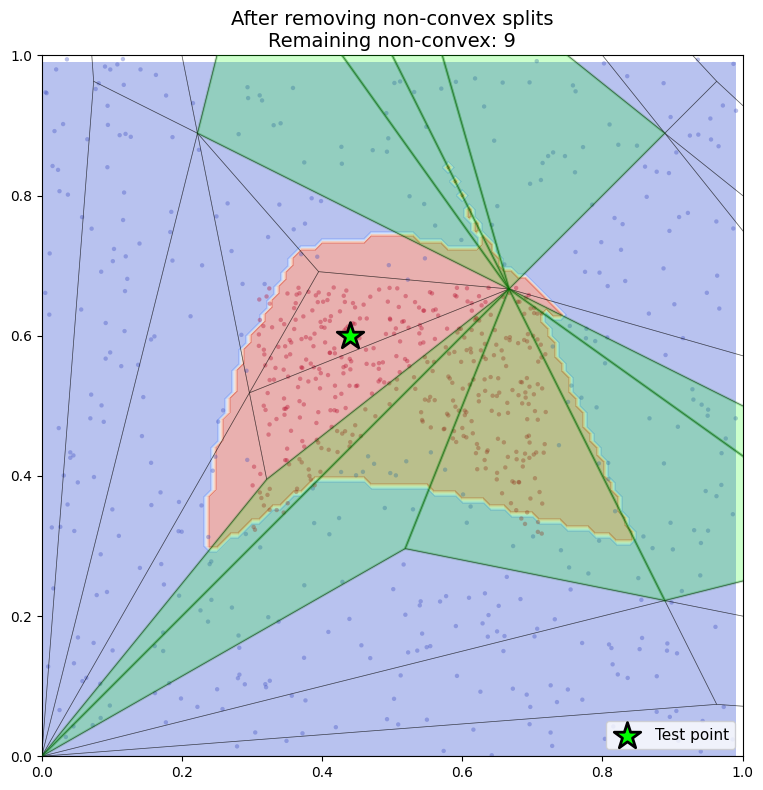

In [17]:
print(f'Leaves before removal: {len(stc_model.leaf_simplexes)}')

keys_to_remove = nonconvex_simplex_keys | same_side_simplex_keys
removed_parents = set()
for key in keys_to_remove:
    node = stc_model.all_nodes_lookup.get(key)
    if node is None or node.parent is None:
        continue
    parent_key = frozenset(node.parent.vertex_indices)
    if parent_key in removed_parents:
        continue
    success = stc_model.tree.remove_by_leaf_key(key)
    if success:
        removed_parents.add(parent_key)

stc_model._build_node_lookup()
stc_model.fit(grid_pts, grid_labels)

print(f'Leaves after removal:  {len(stc_model.leaf_simplexes)}')
print(f'Removed {len(removed_parents)} parent splits')

# Re-run crossing & convexity check on the simplified tree
crossing_after = stc_model.identify_crossing_simplices()
nonconvex_after = set()

if stc_model.is_linear_classifier:
    weights, intercept = stc_model.get_weights_and_intercept()
    for i, info1 in enumerate(crossing_after):
        s1 = info1['simplex']
        for info2 in crossing_after[i+1:]:
            s2 = info2['simplex']
            shared = get_shared_vertices(s1, s2)
            if len(shared) >= 2:
                is_convex, *_ = check_convexity(
                    s1, s2, weights, intercept,
                    global_tree=stc_model.tree, epsilon=EPSILON
                )
                if not is_convex:
                    nonconvex_after.add(frozenset(s1.vertex_indices))
                    nonconvex_after.add(frozenset(s2.vertex_indices))

same_side_after = stc_model.find_same_side_simplices() if stc_model.is_linear_classifier else set()
print(f'Non-convex simplices remaining: {len(nonconvex_after)}')
print(f'Same-side simplices remaining: {len(same_side_after)}')

# Visualize after removal
fig, ax = plt.subplots(figsize=(8, 8))
xy_stc = stc_model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, stc_model.classifier, xx, yy, xy_stc, cmap=plt.cm.coolwarm, alpha=0.4)

for boundary in stc_model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=0.5, alpha=0.4)

for leaf in stc_model.leaf_simplexes:
    simplex_key = frozenset(leaf.vertex_indices)
    if simplex_key in nonconvex_after:
        vertices = np.array(leaf.vertices)
        poly = patches.Polygon(vertices, closed=True, facecolor='lime', alpha=0.2,
                               edgecolor='green', linewidth=2, zorder=6)
        ax.add_patch(poly)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.35)
ax.scatter(*test_point, c='lime', s=400, marker='*',
           edgecolors='k', linewidths=2, zorder=20, label='Test point')

ax.set_title(f'After removing non-convex splits\n'
             f'Remaining non-convex: {len(nonconvex_after)}', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Leaves before removal: 31
Leaves after removal:  15
Removed 8 parent splits
Non-convex simplices remaining: 4
Same-side simplices remaining: 0


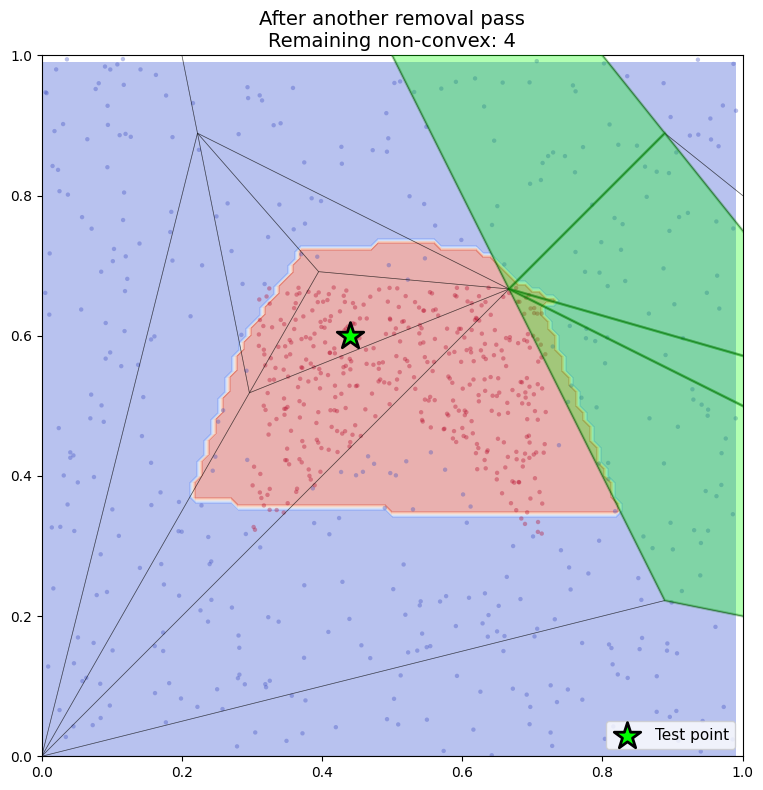

In [18]:
print(f'Leaves before removal: {len(stc_model.leaf_simplexes)}')

keys_to_remove = nonconvex_after | same_side_after
removed_parents = set()
for key in keys_to_remove:
    node = stc_model.all_nodes_lookup.get(key)
    if node is None or node.parent is None:
        continue
    parent_key = frozenset(node.parent.vertex_indices)
    if parent_key in removed_parents:
        continue
    success = stc_model.tree.remove_by_leaf_key(key)
    if success:
        removed_parents.add(parent_key)

stc_model._build_node_lookup()
stc_model.fit(grid_pts, grid_labels)

print(f'Leaves after removal:  {len(stc_model.leaf_simplexes)}')
print(f'Removed {len(removed_parents)} parent splits')

crossing_after = stc_model.identify_crossing_simplices()
nonconvex_after = set()

if stc_model.is_linear_classifier:
    weights, intercept = stc_model.get_weights_and_intercept()
    for i, info1 in enumerate(crossing_after):
        s1 = info1['simplex']
        for info2 in crossing_after[i+1:]:
            s2 = info2['simplex']
            shared = get_shared_vertices(s1, s2)
            if len(shared) >= 2:
                is_convex, *_ = check_convexity(
                    s1, s2, weights, intercept,
                    global_tree=stc_model.tree, epsilon=EPSILON
                )
                if not is_convex:
                    nonconvex_after.add(frozenset(s1.vertex_indices))
                    nonconvex_after.add(frozenset(s2.vertex_indices))

same_side_after = stc_model.find_same_side_simplices() if stc_model.is_linear_classifier else set()
print(f'Non-convex simplices remaining: {len(nonconvex_after)}')
print(f'Same-side simplices remaining: {len(same_side_after)}')

fig, ax = plt.subplots(figsize=(8, 8))
xy_stc = stc_model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, stc_model.classifier, xx, yy, xy_stc, cmap=plt.cm.coolwarm, alpha=0.4)

for boundary in stc_model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=0.5, alpha=0.4)

for leaf in stc_model.leaf_simplexes:
    simplex_key = frozenset(leaf.vertex_indices)
    if simplex_key in nonconvex_after:
        vertices = np.array(leaf.vertices)
        poly = patches.Polygon(vertices, closed=True, facecolor='lime', alpha=0.3,
                               edgecolor='green', linewidth=2, zorder=6)
        ax.add_patch(poly)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=10, edgecolors='none', alpha=0.35)
ax.scatter(*test_point, c='lime', s=400, marker='*',
           edgecolors='k', linewidths=2, zorder=20, label='Test point')

ax.set_title(f'After another removal pass\n'
             f'Remaining non-convex: {len(nonconvex_after)}', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
plt.tight_layout()
plt.show()
